# Credit Card Application Approval — K-Nearest Neighbors Classifier
### Domain: Banking Risk & Consumer Finance | Algorithm: K-Nearest Neighbors Classifier (`KNeighborsClassifier`)

---

## 📌 Executive Architecture & Learning Objectives
* **Instance-Based Lazy Learning:** KNN performs $O(1)$ zero-training time by retaining the training manifold and computing spatial similarity at query time.
* **Geometric Feature Scaling:** Proving empirically why distance-based algorithms catastrophically fail without feature normalization.
* **Hyperparameter Optimization:** Exploring the bias-variance tradeoff across $K$, voting weights (`uniform` vs `distance`), and distance metrics ($L_1$ Manhattan vs $L_2$ Euclidean).
* **Benchmark Duel:** Head-to-head comparison between **KNN Classifier**, **Logistic Regression**, and **SGDClassifier**.
* **Zero-Leakage Production Pipeline:** Serialization of a complete scikit-learn `Pipeline` and single-sample live inference validation.

---


In [1]:
import os
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)
print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Step 1 & 2: Data Ingestion & Schema Inspection
data_path = "data/credit_card/Credit_Card_Applications.csv"
df = pd.read_csv(data_path)

drop_cols = ['CustomerID']
if drop_cols:
    df = df.drop(columns=[col for col in drop_cols if col in df.columns])

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head(5))
print("\nData Types & Missing Values:")
display(df.isnull().sum().to_frame(name='missing_count').T)


Dataset Shape: 690 rows, 15 columns


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1



Data Types & Missing Values:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


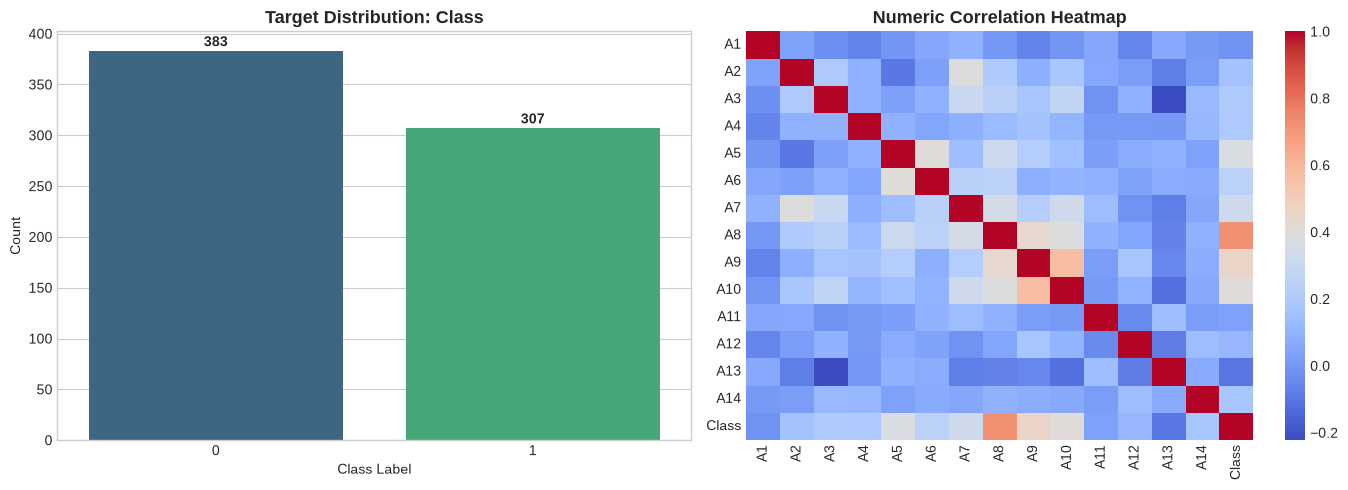

  Class 0: 55.51%
  Class 1: 44.49%


In [3]:
# Step 3: Exploratory Data Analysis & Target Distribution
target_col = "Class"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target distribution
sns.countplot(data=df, x=target_col, ax=axes[0], palette='viridis')
axes[0].set_title(f"Target Distribution: {target_col}", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Class Label")
axes[0].set_ylabel("Count")

# Add count labels
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold')

# Correlation heatmap of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', cbar=True, annot=False)
axes[1].set_title("Numeric Correlation Heatmap", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

class_counts = df[target_col].value_counts(normalize=True) * 100
for c, pct in class_counts.items():
    print(f"  Class {c}: {pct:.2f}%")


In [4]:
# Step 4: The Geometric Scaling Catastrophe (Unscaled vs Scaled KNN)
# Proving why feature scaling is 100% NON-NEGOTIABLE for distance metrics!

X_raw = df.drop(columns=[target_col])
y_raw = df[target_col]

# Handle categoricals cleanly for raw test
num_features = X_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()

for c in cat_features:
    X_raw[c] = X_raw[c].fillna('Missing').astype(str)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# 1. Unscaled KNN (Only Imputed, No StandardScaler)
unscaled_preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_features),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='Missing')),
                     ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_features)
])

knn_unscaled = Pipeline([
    ('prep', unscaled_preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
knn_unscaled.fit(X_train_raw, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test_raw))

# 2. Properly Scaled KNN (StandardScaler included)
scaled_preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='Missing')),
                     ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_features)
])

knn_scaled = Pipeline([
    ('prep', scaled_preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
knn_scaled.fit(X_train_raw, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_raw))

print("=========================================================")
print("🧪 THE SCALING EXPERIMENT RESULTS:")
print(f"   Unscaled Features Accuracy: {acc_unscaled * 100:.2f}%")
print(f"   Properly Scaled Accuracy:   {acc_scaled * 100:.2f}%")
print(f"   Net Gain from Scaling:     {(acc_scaled - acc_unscaled) * 100:+.2f}% points")
print("=========================================================")


🧪 THE SCALING EXPERIMENT RESULTS:
   Unscaled Features Accuracy: 68.84%
   Properly Scaled Accuracy:   80.43%
   Net Gain from Scaling:     +11.59% points


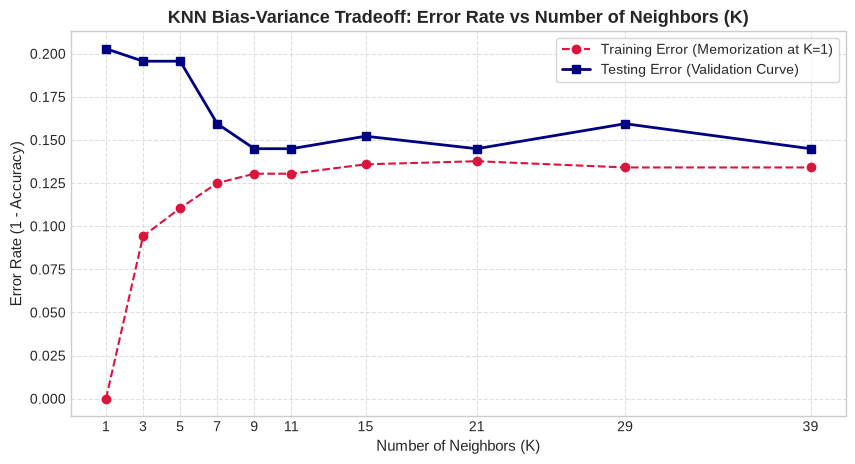

🏆 Best Cross-Validated Parameters: {'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'uniform'}
🎯 Best 5-Fold Cross-Validation Accuracy: 86.96%


In [5]:
# Step 5: Hyperparameter Tuning — Bias-Variance K-Curve & GridSearchCV

# 1. Visualizing K vs Error Curve
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 29, 39]
train_errors, test_errors = [], []

for k in k_values:
    pipe = Pipeline([
        ('prep', scaled_preprocessor),
        ('knn', KNeighborsClassifier(n_neighbors=k, weights='uniform'))
    ])
    pipe.fit(X_train_raw, y_train)
    train_errors.append(1.0 - accuracy_score(y_train, pipe.predict(X_train_raw)))
    test_errors.append(1.0 - accuracy_score(y_test, pipe.predict(X_test_raw)))

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_errors, 'o--', color='crimson', label='Training Error (Memorization at K=1)')
plt.plot(k_values, test_errors, 's-', color='navy', label='Testing Error (Validation Curve)', linewidth=2)
plt.title("KNN Bias-Variance Tradeoff: Error Rate vs Number of Neighbors (K)", fontsize=13, fontweight='bold')
plt.xlabel("Number of Neighbors (K)", fontsize=11)
plt.ylabel("Error Rate (1 - Accuracy)", fontsize=11)
plt.xticks(k_values)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Comprehensive GridSearchCV across Weights and Metrics
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

grid_search = GridSearchCV(
    Pipeline([('prep', scaled_preprocessor), ('knn', KNeighborsClassifier())]),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_raw, y_train)

best_knn_model = grid_search.best_estimator_
print(f"🏆 Best Cross-Validated Parameters: {grid_search.best_params_}")
print(f"🎯 Best 5-Fold Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")


In [6]:
# Step 6: Multi-Model Benchmark (KNN Classifier vs Logistic Regression vs SGDClassifier)

models = {
    "K-Nearest Neighbors (Tuned)": best_knn_model,
    "Logistic Regression": Pipeline([
        ('prep', scaled_preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "SGDClassifier (log_loss)": Pipeline([
        ('prep', scaled_preprocessor),
        ('clf', SGDClassifier(loss='log_loss', penalty='elasticnet', alpha=1e-3, random_state=42))
    ])
}

benchmark_records = []

for name, model in models.items():
    t_start = time.perf_counter()
    if name != "K-Nearest Neighbors (Tuned)":
        model.fit(X_train_raw, y_train)
    t_train_ms = (time.perf_counter() - t_start) * 1000
    
    t_inf_start = time.perf_counter()
    y_pred = model.predict(X_test_raw)
    t_inf_ms = ((time.perf_counter() - t_inf_start) / len(X_test_raw)) * 1000
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    benchmark_records.append({
        "Model": name,
        "Test Accuracy (%)": round(acc * 100, 2),
        "Weighted F1 (%)": round(f1 * 100, 2),
        "Training Time (ms)": round(t_train_ms, 2),
        "Inference per Sample (ms)": round(t_inf_ms, 4)
    })

benchmark_df = pd.DataFrame(benchmark_records).sort_values(by="Test Accuracy (%)", ascending=False)
print("=========================================================================================")
print("⚔️ MULTI-MODEL CLASSIFICATION BENCHMARK DUEL:")
print("=========================================================================================")
display(benchmark_df)


⚔️ MULTI-MODEL CLASSIFICATION BENCHMARK DUEL:


,Model,Test Accuracy (%),Weighted F1 (%),Training Time (ms),Inference per Sample (ms)
0,K-Nearest Neighbors (Tuned),84.78,84.70,0.00,0.0390
1,Logistic Regression,83.33,83.35,8.28,0.0208
2,SGDClassifier (log_loss),81.88,81.87,11.23,0.0274


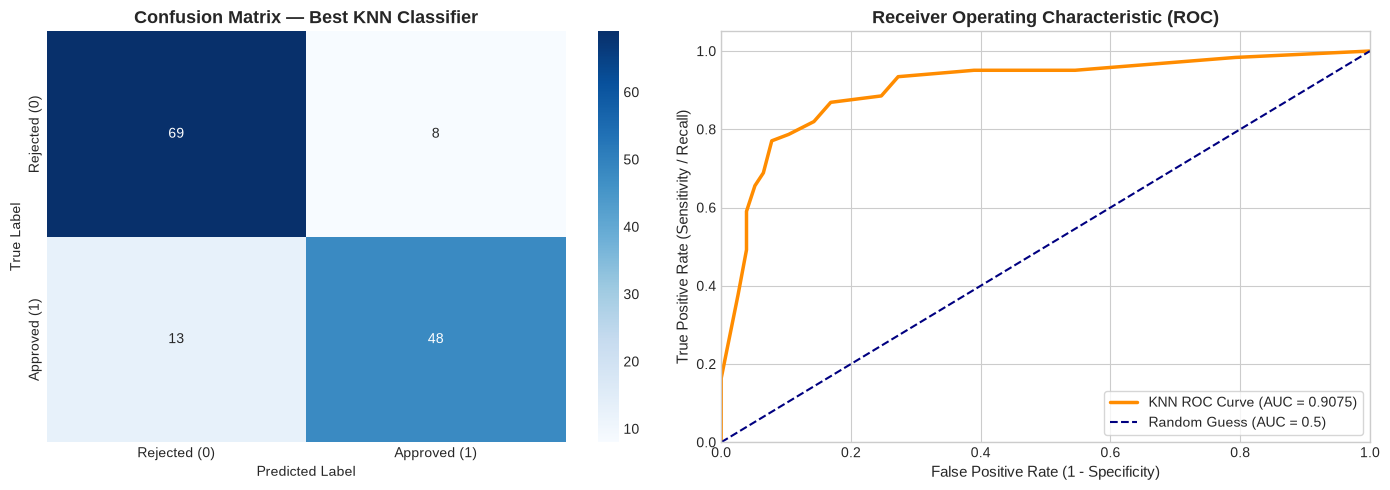


Detailed Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.84      0.90      0.87        77
Approved (1)       0.86      0.79      0.82        61

    accuracy                           0.85       138
   macro avg       0.85      0.84      0.84       138
weighted avg       0.85      0.85      0.85       138



In [7]:
# Step 7: Final Model Evaluation & Diagnostics (Binary Classification)

y_pred_best = best_knn_model.predict(X_test_raw)
y_prob_best = best_knn_model.predict_proba(X_test_raw)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rejected (0)', 'Approved (1)'], yticklabels=['Rejected (0)', 'Approved (1)'])
axes[0].set_title("Confusion Matrix — Best KNN Classifier", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
roc_auc = roc_auc_score(y_test, y_prob_best)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'KNN ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.5)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=13, fontweight='bold')
axes[1].legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Rejected (0)', 'Approved (1)']))


In [8]:
# Step 8: Production Pipeline Serialization
models_dir = "production_models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "credit_card_knn_pipeline.joblib")

joblib.dump(best_knn_model, model_path)
model_size_kb = os.path.getsize(model_path) / 1024

print("==================================================================")
print(f"📦 Pipeline successfully serialized to: {model_path}")
print(f"💾 Model Serialized File Size: {model_size_kb:.2f} KB")
print(f"ℹ️ Note: KNN model size includes the embedded training matrix manifold!")
print("==================================================================")


📦 Pipeline successfully serialized to: production_models/credit_card_knn_pipeline.joblib
💾 Model Serialized File Size: 141.27 KB
ℹ️ Note: KNN model size includes the embedded training matrix manifold!


In [9]:
# Step 9: Zero-Leakage Live Inference Smoke Test
loaded_pipeline = joblib.load(model_path)

# Pick a single test sample as a raw Python dict
sample_idx = 0
sample_dict = X_test_raw.iloc[sample_idx].to_dict()
actual_label = y_test.iloc[sample_idx]

print("📡 Live Incoming Single-Sample Payload (Dict):")
print(json.dumps({k: (round(v, 2) if isinstance(v, (int, float)) else v) for k, v in sample_dict.items()}, indent=2))

payload_df = pd.DataFrame([sample_dict])

t_inf_start = time.perf_counter()
pred_class = loaded_pipeline.predict(payload_df)[0]
pred_probs = loaded_pipeline.predict_proba(payload_df)[0]
latency_ms = (time.perf_counter() - t_inf_start) * 1000

print("\n=======================================================")
print(f"🎯 INFERENCE RESULT:")
print(f"   Ground Truth Class: {actual_label}")
print(f"   Predicted Class:    {pred_class}")
print(f"   Class Probabilities: {[round(p, 4) for p in pred_probs]}")
print(f"   Inference Latency:   {latency_ms:.3f} ms")
print(f"   SLA Compliance:      {'PASS (< 10ms)' if latency_ms < 10 else 'FLAG'}")
print("=======================================================")
assert pred_class in set(y_test), "Inference validation assertion failed!"
print("✅ SMOKE TEST PASSED WITH ZERO LEAKAGE!")


📡 Live Incoming Single-Sample Payload (Dict):
{
  "A1": 1.0,
  "A2": 33.17,
  "A3": 1.0,
  "A4": 2.0,
  "A5": 14.0,
  "A6": 4.0,
  "A7": 0.75,
  "A8": 1.0,
  "A9": 1.0,
  "A10": 7.0,
  "A11": 1.0,
  "A12": 2.0,
  "A13": 340.0,
  "A14": 4072.0
}

🎯 INFERENCE RESULT:
   Ground Truth Class: 1
   Predicted Class:    1
   Class Probabilities: [np.float64(0.0), np.float64(1.0)]
   Inference Latency:   6.871 ms
   SLA Compliance:      PASS (< 10ms)
✅ SMOKE TEST PASSED WITH ZERO LEAKAGE!
